In [1]:
import numpy as np
import cv2
import os
import glob
import matplotlib.pyplot as plt
import h5py
from scipy.optimize import least_squares
import scipy.io as sio


pipeline: 
1. load H5
2. reshape
3. undistort
4. projection matrices
5. triangulation
6. 3d skeleton
7. reproject

In [2]:
# path
root_dir = '/Users/goal0312/Desktop/thesis'
# root_dir = r'\\tsclient\thesis'
input_path = os.path.join(root_dir, '2d_to_3d','5_triangulation')
video_files = sorted(glob.glob(os.path.join(input_path, 'coords_52.h5')))

In [2]:
# load 2d coords

# path
rootdir = '/Volumes/THANH/IceSkating/2d_coords/interpolated_coords'
# rootdir = r'\\tsclient\thesis'
video_files = sorted(glob.glob(os.path.join(rootdir, 'cam*.h5')))

data = {}
for video_file in video_files:
    with h5py.File(video_file,'r') as f:
        data[video_file] = {
            "coords" : f["coords_39"][:],
        }

In [10]:
cam_keys = sorted(data.keys()) 
coords = []

for cam in cam_keys:
    arr = data[cam]["coords"]
    arr = np.transpose(arr, (3, 2, 1,0))  # (17, 2, T)

    coords.append(arr)

In [11]:
coords

[array([[[[ 821.2088623 , 1323.37475586,  788.75646973, ...,
            857.97393799, 1080.68310547,  526.95098877],
          [ 824.57592773, 1323.37475586,  788.27703857, ...,
            857.97393799, 1076.69311523,  527.95800781],
          [ 828.97564697, 1323.37475586,  788.82861328, ...,
            857.97393799, 1073.98046875,  528.29406738],
          ...,
          [ 709.20096798,  790.81811523, 1455.8326416 , ...,
           1092.02001953,  518.6473999 ,  849.10003662],
          [ 715.6267878 ,  791.2355957 , 1460.00244141, ...,
           1088.30236816,  520.90350342,  855.76229604],
          [ 722.17407227,  790.11169434, 1462.49975586, ...,
           1085.72521973,  523.08483887,  872.48828125]],
 
         [[ 263.8999939 ,  275.78967285,  283.75372314, ...,
            178.76612854,  386.18603516,  138.76483154],
          [ 263.1897583 ,  273.68603516,  283.98205566, ...,
            180.69207764,  386.18603516,  139.52456665],
          [ 264.28695679,  274.1007995

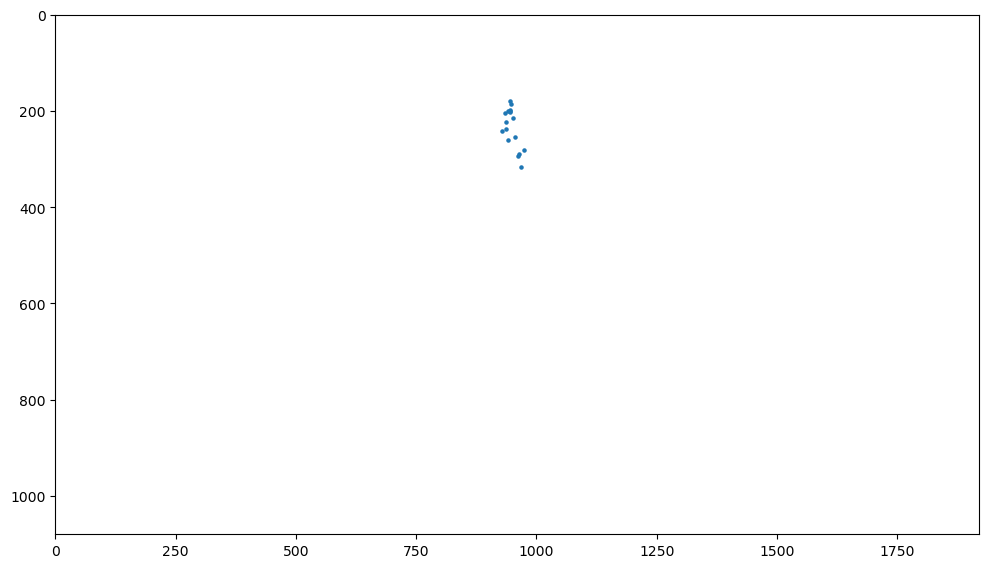

In [13]:
plt.figure(figsize=(12,6.75))
plt.scatter(coords[0][:,0,900,0],coords[0][:,1,900,0],s=5)
plt.xlim(0, 1920)
plt.ylim(1080, 0)   # invert Y (important!)

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [14]:
# Camera 1 intrinsics & distortion
K1 = np.array([[2.72631380e+03, 0.00000000e+00, 9.57747448e+02],
[0.00000000e+00, 2.75788479e+03, 4.82921207e+02],
[0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
distortion1 = np.array([ 6.09422782e-02,  1.03365973e+00,  1.34003666e-02,  1.75159685e-03,
-2.80586518e+00])

In [15]:
# Cam 1 extrinsics - rotation & translation
R1 = np.array([[ 0.28697741],
[ 0.00382006],
[-0.00138285]])
t1 = np.array([[ 0.09598585],
[-0.5431292 ],
[23.84214207]])



In [16]:
# Camera 2 intrinsics 
K2 = np.array([[3.54548296e+03, 0.00000000e+00, 9.60287866e+02],
[0.00000000e+00, 3.54924565e+03, 5.57450277e+02],
[0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
distortion2 = np.array([ 5.22080106e-02,  5.61495738e+00,  1.01498704e-02,  2.81631980e-03,
-2.88237239e+01])

In [17]:
R2 = np.array([[0.09831322],
        [2.50218118],
        [0.27399503]])
t2 = np.array([[-0.71703402],
        [-0.05154335],
        [33.4177848 ]])

In [18]:
# Camera 3 intrinsics
K3 = np.array([[3.25847386e+03, 0.00000000e+00, 9.22522896e+02],
[0.00000000e+00, 3.27790661e+03, 5.28108833e+02],
[0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
distortion3 = np.array([ 7.77164572e-02,  2.92914065e+00,  6.95976175e-04, -2.49305655e-03,
-1.37181983e+01])

In [19]:
R3 = np.array([[ 0.06493758],
[-2.48289991],
[-0.29989151]])
t3 = np.array([[ 1.14692637],
[-0.50242494],
[30.37349303]])

In [20]:
# R1 itself is not a rotation matrix, but a rotation vector (3x1), and cv2.Rodrigues() converts it into a matrix (3x3)
# matrix conversion is needed for later matrix multiplication

R1o, _ = cv2.Rodrigues(R1)
R2o, _ = cv2.Rodrigues(R2)
R3o, _ = cv2.Rodrigues(R3)

In [21]:
# Xcam = R Xworld + t.  - this is how we go from world coordinates to camera coordinates
# by taking 3d points in world coordinates -> rotate & translate -> cam coords.

# X1 = R1 Xold + t1 - that's how we solved for R1 & t1
# now we want R1 to be I & t1 to be 0 => we plugged in and solved for Xold, 
# then we use that new Xold to solve for R2 t2 and R3 t3

# original calibration values
t1_orig = t1.copy()

# we are computing the position of cam 2 and cam 3 as cam 1 is taken as world origin

R2_rel = R2o @ R1o.T
R3_rel = R3o @ R1o.T
t2_rel = t2 - R2_rel @ t1_orig
t3_rel = t3 - R3_rel @ t1_orig

# now define camera 1 as world origin
R1_rel = np.eye(3) # identity matrix
t1_rel = np.zeros((3,1))

In [23]:
coords[0]

array([[[[ 821.2088623 , 1323.37475586,  788.75646973, ...,
           857.97393799, 1080.68310547,  526.95098877],
         [ 824.57592773, 1323.37475586,  788.27703857, ...,
           857.97393799, 1076.69311523,  527.95800781],
         [ 828.97564697, 1323.37475586,  788.82861328, ...,
           857.97393799, 1073.98046875,  528.29406738],
         ...,
         [ 709.20096798,  790.81811523, 1455.8326416 , ...,
          1092.02001953,  518.6473999 ,  849.10003662],
         [ 715.6267878 ,  791.2355957 , 1460.00244141, ...,
          1088.30236816,  520.90350342,  855.76229604],
         [ 722.17407227,  790.11169434, 1462.49975586, ...,
          1085.72521973,  523.08483887,  872.48828125]],

        [[ 263.8999939 ,  275.78967285,  283.75372314, ...,
           178.76612854,  386.18603516,  138.76483154],
         [ 263.1897583 ,  273.68603516,  283.98205566, ...,
           180.69207764,  386.18603516,  139.52456665],
         [ 264.28695679,  274.10079956,  285.64709473, .

In [24]:
# undistort 2d points

def undistort_kpts(kpts, K, dist):
    J, _, T = kpts.shape     # kpts: (17, 2, T)
    out = np.full_like(kpts, np.nan, dtype=np.float64) # 17,2,1500

    for t in range(T):
        pts = kpts[:, :, t].reshape(-1, 1, 2) # 17,1,2 as opencv expected this dimension
        mask = ~np.isnan(pts[:, 0, 0])

        if not np.any(mask): # skip points that are NaN
            continue

        undist = cv2.undistortPoints( 
            pts[mask], K, dist, P=K
        )
        out[mask, :, t] = undist.reshape(-1, 2)

    return out
# kpts[0] = undistort_kpts(kpts[0], K1, distortion1)
# kpts[1] = undistort_kpts(kpts[1], K2, distortion2)
# kpts[2] = undistort_kpts(kpts[2], K3, distortion3)



In [25]:
# P = K [ R | t ] - each P maps 3d -> 2d
# we need P for triangulation & reprojection

P1 = K1 @ np.hstack((R1_rel, t1_rel))
P2 = K2 @ np.hstack((R2_rel, t2_rel))
P3 = K3 @ np.hstack((R3_rel, t3_rel))
proj_mats = [P1, P2, P3]

# triangulation: 
# for camera i: x (2d) = Pi.X (3d). we know Pi and 2d xi => we solve for X

# reprojection: after we compute 3d XYZ, multiply 3d points by P 
# => get the expected location in the image.

A single 2D point in a camera image corresponds to:
All possible 3D points that could project to that pixel in the image.
The 2D point does not give depth
It only gives a direction from the camera center along which the 3D point must lie

The camera is like a pinhole
The pixel (u, v) defines a ray starting at the camera center and pointing into the scene
The unknown 3D point lies somewhere along that ray.

1 camera → infinite 3D points along the ray → depth unknown
2 cameras → 2 rays in 3D → intersect at a point → unique 3D solution (if rays are exact)
3+ cameras → more rays → use least squares (SVD) → find point closest to all rays

In [26]:
# each camera gives a 2d point (u,v). u = horizontal pixel, v = vertical pixel.
# we want to solve for 3d X = (X,Y,Z) so [u v 1] ~ Pi[X Y Z 1]
# camera gives two linear equations for the unknown 3d point for u & v
# so we can solve them with linear algebra

def triangulate_point_DLT(xy_list, P_list):
    """
    xy_list : list of (x, y) 2d points from each camera [(x1,y1),(x2,y2),...]
    P_list  : list of corresponding 3x4 projection matrices [P1 P2 P3]
    Goal: compute the corresponding 3d point X in world coordinates
    """
    A = [] # a matrix A that represents AX = 0, where X is the unknown 3d point. 
    # A is a matrix that stores all the equations coming from all cameras.
    # from x ~ PX. with matrix multiplication we get u,v and then we store those equations in A

    for (x, y), P in zip(xy_list, P_list):
        A.append(x * P[2] - P[0])
        A.append(y * P[2] - P[1])
    # 6x4 matrix from 3 cams x 2 eqs x 4 coeffs in homogeneous coords
    A = np.asarray(A)
    _, _, Vt = np.linalg.svd(A)
    X = Vt[-1]
    return X[:3] / X[3]


In [27]:
def triangulate_sequence(kpts, P_list, min_cams=2):
    """
    kpts   : list of arrays, each (17, 2, T)
    P_list : list of 3x4 projection matrices
    """
    n_cams = len(kpts)
    n_joints, _, T = kpts[0].shape

    XYZ = np.full((T, n_joints, 3), np.nan)

    for t in range(T):
        for j in range(n_joints):

            xy_list = []
            Ps = []

            for c in range(n_cams):
                xy = kpts[c][j, :, t]
                if not np.any(np.isnan(xy)):
                    xy_list.append(xy)
                    Ps.append(P_list[c])

            if len(xy_list) >= min_cams:
                XYZ[t, j] = triangulate_point_DLT(xy_list, Ps)

    return XYZ


In [32]:
p1 = coords[0][:,:,:,0]
p2 = coords[1][:,:,:,0]
p3 = coords[2][:,:,:,0]
kpts = [p1,p2,p3]

In [34]:
len(kpts)

3

In [35]:
XYZ = triangulate_sequence(
    kpts=kpts,          # your [cam][17,2,T]
    P_list=proj_mats,   # [P1, P2, P3]
    min_cams=2
)

print(XYZ.shape)  # (T, 17, 3)

(4200, 17, 3)


In [36]:
XYZ

array([[[-1.08903478e+00, -1.80211048e+00,  2.26268679e+01],
        [-1.08255082e+00, -1.83319067e+00,  2.26185727e+01],
        [-1.07543353e+00, -1.83422390e+00,  2.26343936e+01],
        ...,
        [-9.43377283e-01, -8.50358644e-01,  2.27842985e+01],
        [-8.52595301e-01, -4.17166578e-01,  2.26893085e+01],
        [-9.08779153e-01, -5.08125818e-01,  2.30498794e+01]],

       [[-1.07446408e+00, -1.79460955e+00,  2.26230566e+01],
        [-1.06352243e+00, -1.82518954e+00,  2.26122532e+01],
        [-1.05959671e+00, -1.82941832e+00,  2.26324310e+01],
        ...,
        [-9.20066931e-01, -8.39603904e-01,  2.28068999e+01],
        [-8.49710044e-01, -3.98484708e-01,  2.26907993e+01],
        [-8.91386812e-01, -5.00504025e-01,  2.30711207e+01]],

       [[-1.04447554e+00, -1.78552804e+00,  2.26389640e+01],
        [-1.03301313e+00, -1.81699085e+00,  2.26244354e+01],
        [-1.02959852e+00, -1.82081598e+00,  2.26464427e+01],
        ...,
        [-9.04454050e-01, -8.43618199e-01,

In [37]:
def project_points(XYZ, P):
    """
    XYZ: (T, J, 3)
    P:   (3, 4)
    returns: (T, J, 2)
    """
    T, J, _ = XYZ.shape
    proj = np.full((T, J, 2), np.nan)

    for t in range(T):
        for j in range(J):
            X = XYZ[t, j]
            if np.any(np.isnan(X)):
                continue

            Xh = np.append(X, 1.0)      # (4,)
            xh = P @ Xh                 # (3,)
            if xh[2] <= 1e-6:
                continue

            proj[t, j] = xh[:2] / xh[2]

    return proj
proj_cam0 = project_points(XYZ, P1)
proj_cam1 = project_points(XYZ, P2)
proj_cam2 = project_points(XYZ, P3)

In [38]:
kpts[0][:,:,950]

array([[ 941.89471436,  226.17895508],
       [ 945.98651123,  223.72363281],
       [ 941.15606689,  222.71557617],
       [ 953.45294189,  228.20419312],
       [ 940.18719482,  224.82409668],
       [ 949.93243408,  242.50582886],
       [ 940.18890381,  240.48242188],
       [ 944.03030396,  219.16326904],
       [ 925.83990479,  228.47000122],
       [ 966.71234131,  203.22094727],
       [ 910.07897949,  217.5411377 ],
       [ 957.89678955,  294.62359619],
       [ 957.33551025,  293.50527954],
       [ 936.40838623,  334.43643188],
       [ 974.62554932,  335.17276001],
       [ 936.13250732,  378.56155396],
       [1000.9508667 ,  372.51760864]])

In [34]:
np.argmax(kpts[0][:,0,950])

12

Camera 0: grabbed frame 950, shape: (1080, 1920, 3)


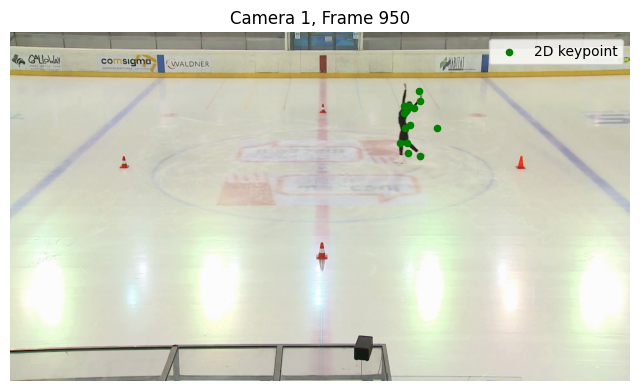

In [ ]:
import cv2

path = '/Volumes/THANH/IceSkating/experiment/stimuli'
video_files = sorted(glob.glob(os.path.join(path, 'chunk1.mp4')))

frame_idx = 950

# ── pick which camera to use ──────────────────────────────────────────────────
cam_idx = 0   # <-- change this (0-based)
# ─────────────────────────────────────────────────────────────────────────────

cap = cv2.VideoCapture(video_files[cam_idx])
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
cap.release()

if not ret:
    print(f"Failed to read frame {frame_idx} from camera {cam_idx}")
else:
    print(f"Camera {cam_idx}: grabbed frame {frame_idx}, shape: {frame.shape}")

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    for j in range(17):
        # original 2D keypoint
        x2d = kpts[cam_idx][j,:,frame_idx]
        plt.scatter(x2d[0], x2d[1], c='g', s=20, label='2D keypoint' if j == 0 else "")

        # reproject using anipose camera
        # X3d = points_3d[frame_idx, j, :]
        # if np.any(np.isnan(X3d)):
        #     continue
        # x_proj = cgroup.cameras[cam_idx].project(X3d.reshape(1, 3)).flatten()
        # plt.scatter(x_proj[0], x_proj[1], c='r', s=50, marker='x', label='Reprojected 3D' if j == 0 else "")

    plt.title(f"Camera {cam_idx + 1}, Frame {frame_idx}")
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.show()

In [29]:
# reproject on frame 100th 
import cv2

# path = '/Volumes/THANH/IceSkating/experiment/stimuli'
path =     '/Users/goal0312/Desktop/thesis/7_experiment/practice_vids'
video_files = sorted(glob.glob(os.path.join(path, 'chunk_1.mp4')))

frame_idx = 4199
frames_sample = []


for i, video_file in enumerate(video_files):
        cap = cv2.VideoCapture(video_file)
        
        # Set to the desired frame index
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        
        ret, frame = cap.read()
        if not ret:
            print(f"Failed to read frame {frame_idx} from camera {i}")
            frame = None
        frames_sample.append(frame)  # store the frame
        
        cap.release()
        if frame is not None:
            print(f"Camera {i}: grabbed frame {frame_idx}, shape: {frame.shape}")
for cam_idx in range(1):
        frame = frames_sample[cam_idx]
        if frame is None:
            continue
        
        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        # plot keypoints
        for j in range(17):
            # original 2D keypoint
            x2d = kpts[cam_idx][j,:,frame_idx]
            plt.scatter(x2d[0], x2d[1], c='g', s=5, label='2D keypoint' if j==0 else "")
            
            # reproject 3D point
            X3d = XYZ[frame_idx, j]
            if np.any(np.isnan(X3d)):
                continue  # skip if triangulation failed
            
            X_h = np.hstack([X3d, 1])  # homogeneous
            x_proj_h = proj_mats[cam_idx] @ X_h
            x_proj = x_proj_h[:2] / x_proj_h[2]
            plt.scatter(x_proj[0], x_proj[1], c='r', s=50, marker='x', label='Reprojected 3D' if j==0 else "")
        
        plt.title(f"Camera {cam_idx+1}, Frame {frame_idx}")
        plt.legend(loc='upper right')
        plt.axis('off')
        plt.show()


IndexError: list index out of range

In [ ]:
# path
path = '/Volumes/THANH/IceSkating/experiment/stimuli'
video_files = sorted(glob.glob(os.path.join(path, '*.mp4')))

# Open videos
caps = [cv2.VideoCapture(v) for v in video_files]

# Get video properties from first camera
fps = caps[0].get(cv2.CAP_PROP_FPS)
width = int(caps[0].get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(caps[0].get(cv2.CAP_PROP_FRAME_HEIGHT))
num_frames = int(caps[0].get(cv2.CAP_PROP_FRAME_COUNT))

# Create video writers (one per camera)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

writers = []
for cam_idx in range(3):
    out_path = f"cam_{cam_idx+1}_reprojection.mp4"
    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
    writers.append(writer)

# -------- MAIN LOOP --------
for frame_idx in range(1500):

    frames = []

    # Read synchronized frames
    for cap in caps:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    if len(frames) != 3:
        break

    # Process each camera
    for cam_idx in range(3):

        frame = frames[cam_idx]

        for j in range(17):

            # -------- Draw original 2D keypoints --------
            x2d = kpts[cam_idx][j, :, frame_idx]
            if not np.any(np.isnan(x2d)):
                cv2.circle(frame,
                           (int(x2d[0]), int(x2d[1])),
                           4,
                           (0,255,0),   # green
                           -1)

            # -------- Reproject 3D --------
            X3d = XYZ[frame_idx, j,:]
            if np.any(np.isnan(X3d)):
                continue

            X_h = np.hstack([X3d, 1])
            x_proj_h = proj_mats[cam_idx] @ X_h
            x_proj = x_proj_h[:2] / x_proj_h[2]

            cv2.drawMarker(frame,
                           (int(x_proj[0]), int(x_proj[1])),
                           (0,0,255),   # red
                           markerType=cv2.MARKER_CROSS,
                           markerSize=12,
                           thickness=2)

        # Write modified frame
        writers[cam_idx].write(frame)

    print(f"Processed frame {frame_idx}/{num_frames}", end="\r")

# Cleanup
for cap in caps:
    cap.release()

for writer in writers:
    writer.release()

print("\nDone.")

Processed frame 1499/8450
Done.


In [ ]:
np.savez("xyz.npz", XYZ=XYZ)

mat = np.load("xyz.npz", allow_pickle=True)

sio.savemat("xyz.mat", {
    "XYZ": mat["XYZ"]
})

In [ ]:
errors = []

for t in range(T):
    for j in range(17):
        X = XYZ[t, j]
        if not np.any(np.isnan(X)):

            X_h = np.append(X, 1)
            x_hat = P1 @ X_h
            x_hat /= x_hat[2]

            x_obs = kpts[0][j, :, t]
            if not np.any(np.isnan(x_obs)):
                err = np.linalg.norm(x_hat[:2] - x_obs)
                errors.append(err)

print("Mean reprojection error:", np.mean(errors))

Mean reprojection error: 8.434065107682654


In [ ]:
for cam_idx, P in enumerate([P1, P2, P3]):
    errs = []
    for t in range(T):
        for j in range(17):
            X = XYZ[t, j]
            if np.any(np.isnan(X)): continue
            x_obs = kpts[cam_idx][j, :, t]
            if np.any(np.isnan(x_obs)): continue
            xh = P @ np.append(X, 1)
            xh /= xh[2]
            errs.append(np.linalg.norm(xh[:2] - x_obs))
    print(f"Cam {cam_idx+1} mean reprojection error: {np.mean(errs):.2f} px")

Cam 1 mean reprojection error: 8.43 px
Cam 2 mean reprojection error: 3.80 px
Cam 3 mean reprojection error: 4.13 px


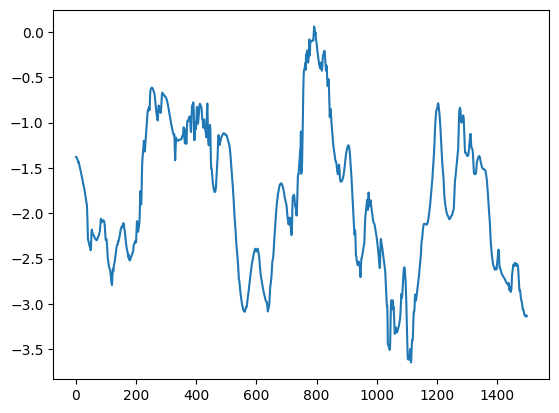

In [ ]:
plt.plot(XYZ[:,10,1])

In [40]:
from scipy.signal import butter, filtfilt
import numpy as np

fps = 50
cutoff = 2  # Hz - experiment with this

def butter_smooth(signal, cutoff, fps, order=4):
    b, a = butter(order, cutoff / (fps/2), btype='low')
    return filtfilt(b, a, signal)

XYZ_smooth = XYZ.copy()

for j in range(17):
    for dim in range(3):  # X, Y, Z
        sig = XYZ[:, j, dim]  # (T,)
        good = ~np.isnan(sig)
        
        if np.sum(good) < 10:
            continue
        
        XYZ_smooth[good, j, dim] = butter_smooth(sig[good], cutoff, fps)

Camera 0: grabbed frame 900, shape: (1080, 1920, 3)
Camera 1: grabbed frame 900, shape: (1080, 1920, 3)
Camera 2: grabbed frame 900, shape: (1080, 1920, 3)


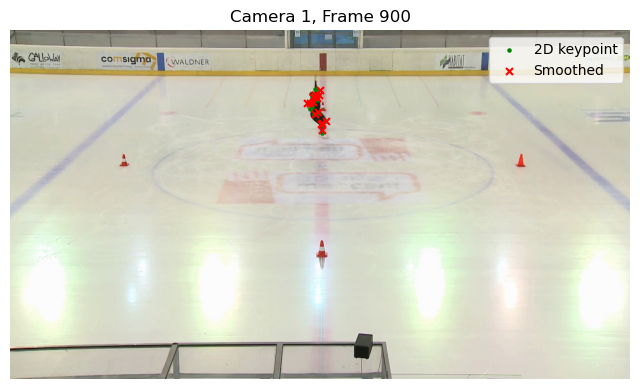

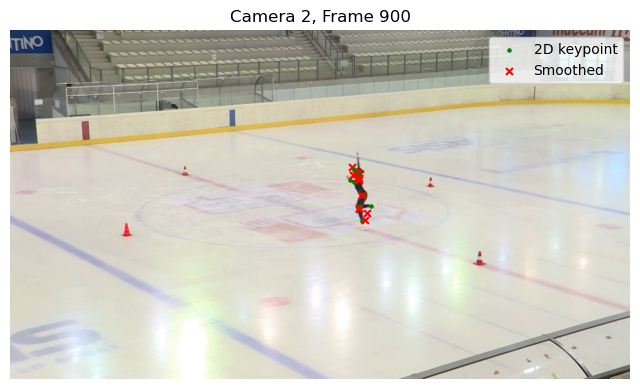

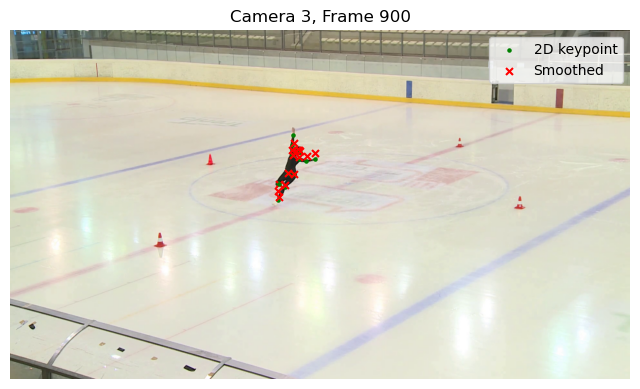

In [44]:
# reproject on frame 100th 
import cv2

path = '/Volumes/THANH/IceSkating/experiment/stimuli'
video_files = sorted(glob.glob(os.path.join(path, '*.mp4')))

frame_idx = 900
frames_sample = []


for i, video_file in enumerate(video_files):
        cap = cv2.VideoCapture(video_file)
        
        # Set to the desired frame index
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        
        ret, frame = cap.read()
        if not ret:
            print(f"Failed to read frame {frame_idx} from camera {i}")
            frame = None
        frames_sample.append(frame)  # store the frame
        
        cap.release()
        if frame is not None:
            print(f"Camera {i}: grabbed frame {frame_idx}, shape: {frame.shape}")
for cam_idx in range(3):
        frame = frames_sample[cam_idx]
        if frame is None:
            continue
        
        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        # plot keypoints
        for j in range(17):
            # original 2D keypoint
            x2d = coords[cam_idx][j,:,frame_idx,0]
            plt.scatter(x2d[0], x2d[1], c='g', s=5, label='2D keypoint' if j==0 else "")
            
            # # reproject 3D point
            # X3d = XYZ[frame_idx, j]
            # if np.any(np.isnan(X3d)):
            #     continue  # skip if triangulation failed

            # smooth
            X3s = XYZ_smooth[frame_idx, j]
            if np.any(np.isnan(X3s)):
                continue  # skip if triangulation failed
            
            # X_h = np.hstack([X3d, 1])  # homogeneous
            # x_proj_h = proj_mats[cam_idx] @ X_h
            # x_proj = x_proj_h[:2] / x_proj_h[2]
            # plt.scatter(x_proj[0], x_proj[1], c='r', s=50, marker='x', label='Reprojected 3D' if j==0 else "")
        
            X_hs = np.hstack([X3s, 1])  # homogeneous
            x_proj_hs = proj_mats[cam_idx] @ X_hs
            x_projs = x_proj_hs[:2] / x_proj_hs[2]
            plt.scatter(x_projs[0], x_projs[1], c='r', s=25, marker='x', label='Smoothed' if j==0 else "")
        
        plt.title(f"Camera {cam_idx+1}, Frame {frame_idx}")
        plt.legend(loc='upper right')
        plt.axis('off')
        plt.show()


In [ ]:
# path
path = '/Volumes/THANH/IceSkating/experiment/stimuli'
video_files = sorted(glob.glob(os.path.join(path, '*.mp4')))

# Open videos
caps = [cv2.VideoCapture(v) for v in video_files]

# Get video properties from first camera
fps = caps[0].get(cv2.CAP_PROP_FPS)
width = int(caps[0].get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(caps[0].get(cv2.CAP_PROP_FRAME_HEIGHT))
num_frames = int(caps[0].get(cv2.CAP_PROP_FRAME_COUNT))

# Create video writers (one per camera)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

writers = []
for cam_idx in range(3):
    out_path = f"cam_{cam_idx+1}_reprojection.mp4"
    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
    writers.append(writer)

# -------- MAIN LOOP --------
for frame_idx in range(1500):

    frames = []

    # Read synchronized frames
    for cap in caps:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    if len(frames) != 3:
        break

    # Process each camera
    for cam_idx in range(3):

        frame = frames[cam_idx]

        for j in range(17):

            # -------- Draw original 2D keypoints --------
            x2d = kpts[cam_idx][j, :, frame_idx]
            if not np.any(np.isnan(x2d)):
                cv2.circle(frame,
                           (int(x2d[0]), int(x2d[1])),
                           4,
                           (0,255,0),   # green
                           -1)

            # -------- Reproject 3D --------
            X3d = XYZ_smooth[frame_idx, j,:]
            if np.any(np.isnan(X3d)):
                continue

            X_h = np.hstack([X3d, 1])
            x_proj_h = proj_mats[cam_idx] @ X_h
            x_proj = x_proj_h[:2] / x_proj_h[2]

            cv2.drawMarker(frame,
                           (int(x_proj[0]), int(x_proj[1])),
                           (0,0,255),   # red
                           markerType=cv2.MARKER_CROSS,
                           markerSize=12,
                           thickness=2)

        # Write modified frame
        writers[cam_idx].write(frame)

    print(f"Processed frame {frame_idx}/{num_frames}", end="\r")

# Cleanup
for cap in caps:
    cap.release()

for writer in writers:
    writer.release()

print("\nDone.")

Processed frame 1499/8450
Done.


Done


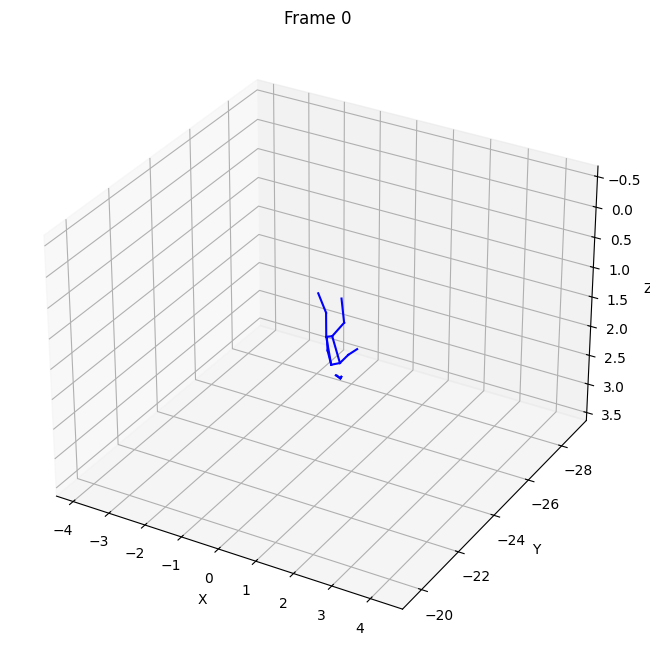

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

# COCO skeleton connections [joint_a, joint_b]
SKELETON = [
    [0, 1], [0, 2],           # nose to eyes
    [1, 3], [2, 4],           # eyes to ears
    [5, 6],                   # shoulders
    [5, 7], [7, 9],           # left arm
    [6, 8], [8, 10],          # right arm
    [5, 11], [6, 12],         # shoulders to hips
    [11, 12],                 # hips
    [11, 13], [13, 15],       # left leg
    [12, 14], [14, 16],       # right leg
]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# get axis limits from data
valid = XYZ_smooth[~np.isnan(XYZ_smooth)]
# adjust these based on your actual coordinate ranges
x_lim = [np.nanmin(XYZ_smooth[:,:,0]), np.nanmax(XYZ_smooth[:,:,0])]
y_lim = [-np.nanmin(XYZ_smooth[:,:,2]), -np.nanmax(XYZ_smooth[:,:,2])]  # Z range for Y axis
z_lim = [-np.nanmin(XYZ_smooth[:,:,1]), -np.nanmax(XYZ_smooth[:,:,1])]  # Y range for Z axis
def update(frame_idx):
    ax.cla()
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_zlim(z_lim)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Frame {frame_idx}')

    joints = XYZ_smooth[frame_idx]  # (17, 3)

    # draw joints
    for j in range(17):
        if not np.any(np.isnan(joints[j])):
            ax.scatter(joints[j,0], joints[j,2], -joints[j,1], c='blue', s=20)

    # draw bones
    for a, b in SKELETON:
        if not np.any(np.isnan(joints[a])) and not np.any(np.isnan(joints[b])):
            ax.plot([joints[a,0], joints[b,0]],
                    [-joints[a,2], -joints[b,2]],
                    [-joints[a,1], -joints[b,1]], 'b-', linewidth=1.5)

ani = animation.FuncAnimation(fig, update, frames=range(0, 1500), 
                               interval=20)  

ani.save('skeleton_3d.mp4', writer='ffmpeg', fps=50, dpi=100)
print("Done")